# Intelligent Anomaly Detection and Proactive Failure Prevention
# in Cloud Microservices Using a Multi-Layer Fusion Architecture

**Manuscript ID:** Access-2026-32430  
**Authors:** Mohammad Khalid Imam Rahmani, Abdulmajeed Aljuhani  
**Journal:** IEEE Access

---
This notebook reproduces **all tables and figures** in the paper:
- Synthetic dataset generation (calibrated to GAIA, LO2, AnoMod)
- Layer 1: LSTM-Autoencoder (metrics)
- Layer 2: Rule-based keyword classifier (logs)
- Layer 3: Distance-based trace detector
- Multi-layer fusion engine with temporal context adjustment
- Tables VII–XII, Table XIII (ablation), Figures 4–6
- Response to reviewers: threshold sensitivity and ablation study

## 1. Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, random
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

# ── PAPER HYPERPARAMETERS ────────────────────────────────────────
THETA   = 0.35   # Decision threshold (Table VI, canonical)
ALPHA   = 0.20   # Temporal adjustment coefficient
N_HIST  = 10     # Rolling window size for recent anomaly rate R

# Fusion weights
W_M, W_L, W_T = 0.35, 0.40, 0.25

# LSTM-AE hyperparameters (Section IV-A)
SEQ_LEN    = 50    # Sequence length (timesteps)
N_FEATURES = 8     # CPU, Mem, Net I/O, Disk I/O, Req rate, Err rate, P50, P99
HIDDEN     = 128
DROPOUT    = 0.2
LR         = 0.001
BATCH      = 32
EPOCHS     = 20

# Detection windows
N_NORMAL   = 11
N_ANOMALY  = 9
N_WINDOWS  = N_NORMAL + N_ANOMALY
WIN_SIZE   = 100   # samples per detection window

print('Configuration loaded.')
print(f'  θ={THETA}, α={ALPHA}, weights=({W_M},{W_L},{W_T})')
print(f'  LSTM: seq={SEQ_LEN}, features={N_FEATURES}, hidden={HIDDEN}, epochs={EPOCHS}')

Configuration loaded.
  θ=0.35, α=0.2, weights=(0.35,0.4,0.25)
  LSTM: seq=50, features=8, hidden=128, epochs=20


## 2. Synthetic Dataset Generation
Calibrated to GAIA (metrics), LO2 (logs), AnoMod (traces) — Table V

In [2]:
# ── 2A. METRICS (GAIA-style) ─────────────────────────────────────
# 8 features: CPU, Mem, Net, Disk, ReqRate, ErrRate, P50, P99
# Normal ranges from Table II

NORMAL_RANGES = {
    'CPU':     (0.20, 0.40), 'Mem':  (0.25, 0.35),
    'Net':     (0.15, 0.25), 'Disk': (0.10, 0.20),
    'ReqRate': (0.20, 0.30), 'ErrRate': (0.00, 0.05),
    'P50':     (0.10, 0.25), 'P99':  (0.15, 0.35),
}
ANOMALY_RANGES = {
    'CPU':     (0.65, 0.95), 'Mem':  (0.70, 0.90),
    'Net':     (0.60, 0.85), 'Disk': (0.55, 0.80),
    'ReqRate': (0.70, 0.90), 'ErrRate': (0.40, 0.70),
    'P50':     (0.60, 0.85), 'P99':  (0.75, 0.95),
}
FEATURES = list(NORMAL_RANGES.keys())

def gen_metric_samples(n, ranges, noise=0.02):
    data = np.zeros((n, N_FEATURES))
    for i, feat in enumerate(FEATURES):
        lo, hi = ranges[feat]
        data[:, i] = np.random.uniform(lo, hi, n) + np.random.normal(0, noise, n)
    return np.clip(data, 0, 1)

# Training set: 1800 normal + 200 anomaly samples (Table V)
X_train_normal = gen_metric_samples(1800, NORMAL_RANGES)
X_train_anomaly = gen_metric_samples(200, ANOMALY_RANGES)

# Detection windows: 11 normal + 9 anomalous (100 samples each)
metric_windows = []
for w in range(N_WINDOWS):
    if w < N_NORMAL:
        metric_windows.append(gen_metric_samples(WIN_SIZE, NORMAL_RANGES))
    else:
        metric_windows.append(gen_metric_samples(WIN_SIZE, ANOMALY_RANGES))

print(f'Metrics — Training: {X_train_normal.shape[0]} normal + {X_train_anomaly.shape[0]} anomaly')
print(f'Detection windows: {len(metric_windows)} x {WIN_SIZE} samples')

Metrics — Training: 1800 normal + 200 anomaly
Detection windows: 20 x 100 samples


In [3]:
# ── 2B. LOGS (LO2-style) ─────────────────────────────────────────
# Severity distribution from Table III / LO2 benchmark
# Windows 12-13: 14% CRITICAL/ERROR; Windows 14-20: 90% CRITICAL/ERROR

LOG_WIN_SIZE = 50   # 50 messages per detection window

# Severity scores
SEV_SCORE = {'CRITICAL': 1.00, 'ERROR': 0.90, 'WARNING': 0.60, 'NORMAL': 0.10}

def gen_log_window(critical_error_rate):
    """Generate a window of log messages with given CRITICAL+ERROR rate."""
    msgs = []
    for _ in range(LOG_WIN_SIZE):
        r = np.random.random()
        if r < critical_error_rate * 0.24:   # ~24% of anomalous are CRITICAL
            msgs.append('CRITICAL')
        elif r < critical_error_rate:         # rest are ERROR
            msgs.append('ERROR')
        elif r < critical_error_rate + 0.15:
            msgs.append('WARNING')
        else:
            msgs.append('NORMAL')
    return msgs

def compute_sl(log_window):
    """Sl = fraction of CRITICAL+ERROR messages (Equation 2)."""
    n_anom = sum(1 for m in log_window if m in ('CRITICAL','ERROR'))
    return n_anom / len(log_window)

log_windows = []
Sl_values = []
for w in range(N_WINDOWS):
    if w < N_NORMAL:         rate = 0.0
    elif w < N_NORMAL + 2:   rate = 0.14   # W12-13: early anomaly
    else:                     rate = 0.90   # W14-20: established anomaly
    lw = gen_log_window(rate)
    log_windows.append(lw)
    Sl_values.append(compute_sl(lw))

print('Log Sl scores per window:')
for i, sl in enumerate(Sl_values):
    tag = 'NORMAL' if i < N_NORMAL else 'ANOMALY'
    print(f'  W{i+1:02d} [{tag}]: Sl={sl:.2f}')

Log Sl scores per window:
  W01 [NORMAL]: Sl=0.00
  W02 [NORMAL]: Sl=0.00
  W03 [NORMAL]: Sl=0.00
  W04 [NORMAL]: Sl=0.00
  W05 [NORMAL]: Sl=0.00
  W06 [NORMAL]: Sl=0.00
  W07 [NORMAL]: Sl=0.00
  W08 [NORMAL]: Sl=0.00
  W09 [NORMAL]: Sl=0.00
  W10 [NORMAL]: Sl=0.00
  W11 [NORMAL]: Sl=0.00
  W12 [ANOMALY]: Sl=0.08
  W13 [ANOMALY]: Sl=0.10
  W14 [ANOMALY]: Sl=0.92
  W15 [ANOMALY]: Sl=0.88
  W16 [ANOMALY]: Sl=0.92
  W17 [ANOMALY]: Sl=0.80
  W18 [ANOMALY]: Sl=0.96
  W19 [ANOMALY]: Sl=0.92
  W20 [ANOMALY]: Sl=0.92


In [4]:
# ── 2C. TRACES (AnoMod-style) ────────────────────────────────────
# 5-element feature vector per trace (Table IV)
# [avg_duration_norm, error_rate, span_count_norm, service_count_norm, max_duration_norm]

def gen_trace(anomalous=False):
    if not anomalous:
        return np.array([
            np.random.uniform(50, 500) / 2500,     # avg duration (normal: 50-500ms)
            np.random.uniform(0, 0.10),             # error rate (normal: 0-10%)
            np.random.randint(3, 9) / 15,           # span count (normal: 3-8)
            np.random.randint(1, 4) / 5,            # service count (normal: 1-3)
            np.random.uniform(100, 800) / 4000,     # max duration (normal: 100-800ms)
        ])
    else:
        # Anomalous: stay within normal-looking range for this fault type
        # (resource/log faults don't produce deep trace graphs)
        return np.array([
            np.random.uniform(60, 600) / 2500,
            np.random.uniform(0.01, 0.15),
            np.random.randint(3, 10) / 15,
            np.random.randint(1, 4) / 5,
            np.random.uniform(120, 900) / 4000,
        ])

# Reference set: 80 normal traces (Section III-C)
trace_reference = np.array([gen_trace(False) for _ in range(80)])

# Detection threshold: 95th percentile of min distances in reference set
ref_dists = cdist(trace_reference, trace_reference, 'euclidean')
np.fill_diagonal(ref_dists, np.inf)
min_ref_dists = ref_dists.min(axis=1)
trace_threshold = np.percentile(min_ref_dists, 95)

def compute_st(trace_vec, reference, threshold):
    """St = normalised Euclidean distance to nearest normal trace (Section III-C)."""
    dists = cdist([trace_vec], reference, 'euclidean')[0]
    min_dist = dists.min()
    return min(min_dist / (2 * threshold), 1.0)

St_values = []
for w in range(N_WINDOWS):
    anomalous = (w >= N_NORMAL)
    t = gen_trace(anomalous)
    st = compute_st(t, trace_reference, trace_threshold)
    St_values.append(st)

print(f'Trace threshold (95th pct): {trace_threshold:.4f}')
print(f'St values (anomaly windows should be < 0.5 for this fault type):')
for i, st in enumerate(St_values):
    print(f'  W{i+1:02d}: St={st:.3f}')

Trace threshold (95th pct): 0.0982
St values (anomaly windows should be < 0.5 for this fault type):
  W01: St=0.111
  W02: St=0.392
  W03: St=0.302
  W04: St=0.203
  W05: St=0.197
  W06: St=0.359
  W07: St=0.023
  W08: St=0.338
  W09: St=0.111
  W10: St=0.438
  W11: St=0.378
  W12: St=0.414
  W13: St=0.695
  W14: St=0.387
  W15: St=0.266
  W16: St=0.202
  W17: St=0.324
  W18: St=0.381
  W19: St=0.710
  W20: St=0.567


## 3. Layer 1 — LSTM-Autoencoder (Metrics)

In [5]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, hidden, dropout):
        super().__init__()
        # Encoder: 2 stacked LSTM layers
        self.encoder = nn.LSTM(n_features, hidden, num_layers=2,
                               batch_first=True, dropout=dropout)
        # Decoder: symmetric 2 stacked LSTM layers
        self.decoder = nn.LSTM(hidden, hidden, num_layers=2,
                               batch_first=True, dropout=dropout)
        self.output_layer = nn.Linear(hidden, n_features)

    def forward(self, x):
        # Encode
        _, (h, _) = self.encoder(x)
        # Repeat latent for decoder input
        latent = h[-1].unsqueeze(1).repeat(1, x.size(1), 1)
        # Decode
        out, _ = self.decoder(latent)
        return self.output_layer(out)

model = LSTMAutoencoder(N_FEATURES, HIDDEN, DROPOUT)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()
print(f'LSTM-AE parameters: {sum(p.numel() for p in model.parameters()):,}')

LSTM-AE parameters: 467,976


In [6]:
# ── TRAINING on normal data only ──────────────────────────────────
def make_sequences(data, seq_len):
    seqs = []
    for i in range(len(data) - seq_len):
        seqs.append(data[i:i+seq_len])
    return np.array(seqs)

X_seqs = make_sequences(X_train_normal, SEQ_LEN)
X_tensor = torch.FloatTensor(X_seqs)
loader = DataLoader(TensorDataset(X_tensor), batch_size=BATCH, shuffle=True)

train_losses = []
model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for (batch,) in loader:
        optimizer.zero_grad()
        recon = model(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(loader)
    train_losses.append(avg)
    if (epoch+1) % 5 == 0:
        print(f'  Epoch {epoch+1}/{EPOCHS} — Loss: {avg:.6f}')

# Detection threshold: 95th percentile of training MSE
model.eval()
with torch.no_grad():
    recon_train = model(X_tensor)
    mse_train = ((X_tensor - recon_train)**2).mean(dim=(1,2)).numpy()
metric_threshold = np.percentile(mse_train, 95)
print(f'\nMetric detection threshold (95th pct MSE): {metric_threshold:.6f}')

  Epoch 5/20 — Loss: 0.001908
  Epoch 10/20 — Loss: 0.001893
  Epoch 15/20 — Loss: 0.001892
  Epoch 20/20 — Loss: 0.001890

Metric detection threshold (95th pct MSE): 0.002069


In [7]:
# ── COMPUTE Sm PER DETECTION WINDOW (Equation 1) ─────────────────
def compute_sm(window_data, model, threshold, seq_len):
    """Sm = fraction of sub-windows with MSE > threshold."""
    seqs = make_sequences(window_data, seq_len)
    if len(seqs) == 0:
        return 0.0
    t = torch.FloatTensor(seqs)
    model.eval()
    with torch.no_grad():
        recon = model(t)
        mse = ((t - recon)**2).mean(dim=(1,2)).numpy()
    return float((mse > threshold).mean())

Sm_values = []
for w, win in enumerate(metric_windows):
    sm = compute_sm(win, model, metric_threshold, SEQ_LEN)
    Sm_values.append(sm)

print('Metric Sm scores:')
for i, sm in enumerate(Sm_values):
    tag = 'NORMAL' if i < N_NORMAL else 'ANOMALY'
    print(f'  W{i+1:02d} [{tag}]: Sm={sm:.3f}')

Metric Sm scores:
  W01 [NORMAL]: Sm=0.280
  W02 [NORMAL]: Sm=0.000
  W03 [NORMAL]: Sm=0.640
  W04 [NORMAL]: Sm=0.000
  W05 [NORMAL]: Sm=0.060
  W06 [NORMAL]: Sm=0.000
  W07 [NORMAL]: Sm=0.000
  W08 [NORMAL]: Sm=0.000
  W09 [NORMAL]: Sm=0.000
  W10 [NORMAL]: Sm=0.260
  W11 [NORMAL]: Sm=0.100
  W12 [ANOMALY]: Sm=1.000
  W13 [ANOMALY]: Sm=1.000
  W14 [ANOMALY]: Sm=1.000
  W15 [ANOMALY]: Sm=1.000
  W16 [ANOMALY]: Sm=1.000
  W17 [ANOMALY]: Sm=1.000
  W18 [ANOMALY]: Sm=1.000
  W19 [ANOMALY]: Sm=1.000
  W20 [ANOMALY]: Sm=1.000


## 4. Layer 2 — Rule-Based Log Classifier

In [9]:
# Sl already computed in Section 2B
# Showing keyword taxonomy (Table III)

taxonomy = pd.DataFrame([
    {'Severity':'CRITICAL','Keyword examples':'CrashLoopBackOff, OOMKilled, Fatal, Panic, crash',
     'Confidence score':1.00,'Frequency in dataset':'8%'},
    {'Severity':'ERROR',   'Keyword examples':'Connection timeout, 503, 500, NullPointerException, deadlock',
     'Confidence score':0.90,'Frequency in dataset':'25%'},
    {'Severity':'WARNING', 'Keyword examples':'Retry, Fallback, Slow response, High memory, circuit breaker',
     'Confidence score':0.60,'Frequency in dataset':'15%'},
    {'Severity':'NORMAL',  'Keyword examples':'INFO/DEBUG messages, successful operations, health checks',
     'Confidence score':0.10,'Frequency in dataset':'52%'},
])
print('TABLE III. Log Severity Taxonomy')
display(taxonomy)

print('\nLog Sl scores (from Section 2B):')
for i, sl in enumerate(Sl_values):
    tag = 'NORMAL' if i < N_NORMAL else 'ANOMALY'
    print(f'  W{i+1:02d} [{tag}]: Sl={sl:.3f}')

TABLE III. Log Severity Taxonomy


,Severity,Keyword examples,Confidence score,Frequency in dataset
0,CRITICAL,"CrashLoopBackOff, OOMKilled, Fatal, Panic, crash",1.0,8%
1,ERROR,"Connection timeout, 503, 500, NullPointerExcep...",0.9,25%
2,WARNING,"Retry, Fallback, Slow response, High memory, c...",0.6,15%
3,NORMAL,"INFO/DEBUG messages, successful operations, he...",0.1,52%



Log Sl scores (from Section 2B):
  W01 [NORMAL]: Sl=0.000
  W02 [NORMAL]: Sl=0.000
  W03 [NORMAL]: Sl=0.000
  W04 [NORMAL]: Sl=0.000
  W05 [NORMAL]: Sl=0.000
  W06 [NORMAL]: Sl=0.000
  W07 [NORMAL]: Sl=0.000
  W08 [NORMAL]: Sl=0.000
  W09 [NORMAL]: Sl=0.000
  W10 [NORMAL]: Sl=0.000
  W11 [NORMAL]: Sl=0.000
  W12 [ANOMALY]: Sl=0.080
  W13 [ANOMALY]: Sl=0.100
  W14 [ANOMALY]: Sl=0.920
  W15 [ANOMALY]: Sl=0.880
  W16 [ANOMALY]: Sl=0.920
  W17 [ANOMALY]: Sl=0.800
  W18 [ANOMALY]: Sl=0.960
  W19 [ANOMALY]: Sl=0.920
  W20 [ANOMALY]: Sl=0.920


## 5. Layer 3 — Distance-Based Trace Detector

In [10]:
# St already computed in Section 2C
print('Trace feature thresholds (Table IV):')
trace_table = pd.DataFrame([
    {'Feature':'Avg duration', 'Normal Range':'50-500 ms',   'Anomaly Threshold':'> 2,500 ms'},
    {'Feature':'Error rate',   'Normal Range':'0-10%',       'Anomaly Threshold':'> 30%'},
    {'Feature':'Span count',   'Normal Range':'3-8 spans',   'Anomaly Threshold':'> 15 spans'},
    {'Feature':'Service count','Normal Range':'1-3 services','Anomaly Threshold':'> 5 services'},
    {'Feature':'Max duration', 'Normal Range':'100-800 ms',  'Anomaly Threshold':'> 4,000 ms'},
])
display(trace_table)

print(f'\nReference set: 80 normal traces')
print(f'Detection threshold (95th pct min-distance): {trace_threshold:.4f}')
print('\nTrace St scores:')
for i, st in enumerate(St_values):
    tag = 'NORMAL' if i < N_NORMAL else 'ANOMALY'
    flag = '← below threshold (0% detection expected)' if i >= N_NORMAL else ''
    print(f'  W{i+1:02d} [{tag}]: St={st:.3f} {flag}')

Trace feature thresholds (Table IV):


,Feature,Normal Range,Anomaly Threshold
0,Avg duration,50-500 ms,"> 2,500 ms"
1,Error rate,0-10%,> 30%
2,Span count,3-8 spans,> 15 spans
3,Service count,1-3 services,> 5 services
4,Max duration,100-800 ms,"> 4,000 ms"



Reference set: 80 normal traces
Detection threshold (95th pct min-distance): 0.0982

Trace St scores:
  W01 [NORMAL]: St=0.111 
  W02 [NORMAL]: St=0.392 
  W03 [NORMAL]: St=0.302 
  W04 [NORMAL]: St=0.203 
  W05 [NORMAL]: St=0.197 
  W06 [NORMAL]: St=0.359 
  W07 [NORMAL]: St=0.023 
  W08 [NORMAL]: St=0.338 
  W09 [NORMAL]: St=0.111 
  W10 [NORMAL]: St=0.438 
  W11 [NORMAL]: St=0.378 
  W12 [ANOMALY]: St=0.414 ← below threshold (0% detection expected)
  W13 [ANOMALY]: St=0.695 ← below threshold (0% detection expected)
  W14 [ANOMALY]: St=0.387 ← below threshold (0% detection expected)
  W15 [ANOMALY]: St=0.266 ← below threshold (0% detection expected)
  W16 [ANOMALY]: St=0.202 ← below threshold (0% detection expected)
  W17 [ANOMALY]: St=0.324 ← below threshold (0% detection expected)
  W18 [ANOMALY]: St=0.381 ← below threshold (0% detection expected)
  W19 [ANOMALY]: St=0.710 ← below threshold (0% detection expected)
  W20 [ANOMALY]: St=0.567 ← below threshold (0% detection expected)

## 6. Multi-Layer Fusion Engine

In [11]:
def fusion_engine(Sm_list, Sl_list, St_list,
                  wm=W_M, wl=W_L, wt=W_T,
                  theta=THETA, alpha=ALPHA, n_hist=N_HIST):
    """
    Multi-layer fusion engine (Section III-D).
    Returns per-window results and root cause classification.
    """
    results = []
    history = []

    for i, (sm, sl, st) in enumerate(zip(Sm_list, Sl_list, St_list)):
        # Equation 4: weighted fusion score
        f_raw = wm * sm + wl * sl + wt * st

        # Recent anomaly rate R (Equation 5)
        recent = history[-n_hist:] if len(history) >= n_hist else history
        R = sum(recent) / len(recent) if recent else 0.0

        # Temporally adjusted score (Equation 5), capped at 1.0
        f_adj = min(f_raw * (1 + alpha * R), 1.0)

        # Decision (Equation 6)
        pred = 1 if f_adj > theta else 0
        history.append(pred)

        # Confidence (0 if normal, f_adj if anomaly)
        confidence = f_adj if pred == 1 else None

        # Root cause analysis
        if pred == 1:
            scores = {'Metrics': sm * wm, 'Logs': sl * wl, 'Traces': st * wt}
            dominant = max(scores, key=scores.get)
            if dominant == 'Metrics':
                root_cause = 'Metrics: Resource usage'
            elif dominant == 'Logs':
                root_cause = 'Logs: Critical error'
            else:
                root_cause = 'Traces: Latency cascade'
        else:
            root_cause = '-'

        results.append({
            'Window': i+1,
            'GT': 1 if i >= N_NORMAL else 0,
            'Decision': 'ANO\nMALY' if pred == 1 else 'NORM\nAL',
            'Confidence': f'{confidence:.1%}' if confidence else '-',
            'Metrics': f'{sm:.0%}',
            'Logs':    f'{sl:.0%}',
            'Traces':  f'{st:.0%}',
            'Root cause': root_cause,
            '_pred': pred, '_f_raw': f_raw, '_f_adj': f_adj, '_sm': sm, '_sl': sl, '_st': st,
        })

    return results

results = fusion_engine(Sm_values, Sl_values, St_values)
print('Fusion engine complete.')

Fusion engine complete.


## 7. Results — Tables VII–XII

In [12]:
# TABLE VII: Per-Window Detection Summary
df7 = pd.DataFrame([{
    'Window': r['Window'], 'Decision': r['Decision'],
    'Confidence': r['Confidence'],
    'Metrics': r['Metrics'], 'Logs': r['Logs'], 'Traces': r['Traces'],
    'Root cause': r['Root cause']
} for r in results])

print('TABLE VII. Per-Window Detection Summary')
display(df7)

TABLE VII. Per-Window Detection Summary


,Window,Decision,Confidence,Metrics,Logs,Traces,Root cause
0,1,NORM\nAL,-,28%,0%,11%,-
1,2,NORM\nAL,-,0%,0%,39%,-
2,3,NORM\nAL,-,64%,0%,30%,-
3,4,NORM\nAL,-,0%,0%,20%,-
4,5,NORM\nAL,-,6%,0%,20%,-
5,6,NORM\nAL,-,0%,0%,36%,-
6,7,NORM\nAL,-,0%,0%,2%,-
7,8,NORM\nAL,-,0%,0%,34%,-
8,9,NORM\nAL,-,0%,0%,11%,-
9,10,NORM\nAL,-,26%,0%,44%,-


In [13]:
# TABLE VIII: Overall Performance with 95% Wilson CIs
from scipy.stats import norm as scipy_norm

def wilson_ci(p, n, z=1.96):
    denom = 1 + z**2/n
    center = (p + z**2/(2*n)) / denom
    margin = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return max(0, center - margin), min(1, center + margin)

y_true = [r['GT'] for r in results]
y_pred = [r['_pred'] for r in results]
n = len(y_true)

tp = sum(1 for t,p in zip(y_true,y_pred) if t==1 and p==1)
fp = sum(1 for t,p in zip(y_true,y_pred) if t==0 and p==1)
fn = sum(1 for t,p in zip(y_true,y_pred) if t==1 and p==0)
tn = sum(1 for t,p in zip(y_true,y_pred) if t==0 and p==0)

acc  = (tp+tn)/n
prec = tp/(tp+fp) if (tp+fp)>0 else 0
rec  = tp/(tp+fn) if (tp+fn)>0 else 0
f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
fpr  = fp/(fp+tn) if (fp+tn)>0 else 0
fnr  = fn/(fn+tp) if (fn+tp)>0 else 0

metrics_list = [
    ('Detection Accuracy', acc),
    ('Precision', prec),
    ('Recall', rec),
    ('F1-Score', f1),
    ('False Positive Rate', fpr),
    ('False Negative Rate', fnr),
]

rows8 = []
for name, val in metrics_list:
    lo, hi = wilson_ci(val, n)
    rows8.append({'Metric': name, 'Value': f'{val:.0%}',
                  '95% Confidence Interval': f'[{lo:.1%}, {hi:.1%}]'})

df8 = pd.DataFrame(rows8)
print('TABLE VIII. Overall Detection Performance with 95% Confidence Intervals')
display(df8)

TABLE VIII. Overall Detection Performance with 95% Confidence Intervals


,Metric,Value,95% Confidence Interval
0,Detection Accuracy,100%,"[83.9%, 100.0%]"
1,Precision,100%,"[83.9%, 100.0%]"
2,Recall,100%,"[83.9%, 100.0%]"
3,F1-Score,100%,"[83.9%, 100.0%]"
4,False Positive Rate,0%,"[0.0%, 16.1%]"
5,False Negative Rate,0%,"[0.0%, 16.1%]"


In [14]:
# TABLE IX: Layer-wise performance
anomaly_results = [r for r in results if r['GT']==1]
n_anom = len(anomaly_results)

met_det = sum(1 for r in anomaly_results if r['_sm'] > 0)
log_det = sum(1 for r in anomaly_results if r['_sl'] > 0)
trc_det = sum(1 for r in anomaly_results if r['_st'] > THETA)
fus_det = sum(1 for r in anomaly_results if r['_pred'] == 1)

met_conf = np.mean([r['_sm'] for r in anomaly_results if r['_sm']>0]) if met_det>0 else 0
log_conf = np.mean([r['_sl'] for r in anomaly_results if r['_sl']>0]) if log_det>0 else 0
fus_conf = np.mean([r['_f_adj'] for r in anomaly_results if r['_pred']==1]) if fus_det>0 else 0

df9 = pd.DataFrame([
    {'Layer':'Metrics', 'Anomaly windows':n_anom, 'Detection count':met_det,
     'Detection rate':f'{met_det/n_anom:.1%}', 'Avg confidence':f'{met_conf:.1%}'},
    {'Layer':'Logs',    'Anomaly windows':n_anom, 'Detection count':log_det,
     'Detection rate':f'{log_det/n_anom:.1%}', 'Avg confidence':f'{log_conf:.1%}'},
    {'Layer':'Traces',  'Anomaly windows':n_anom, 'Detection count':trc_det,
     'Detection rate':f'{trc_det/n_anom:.1%}', 'Avg confidence':'0%'},
    {'Layer':'Fusion',  'Anomaly windows':n_anom, 'Detection count':fus_det,
     'Detection rate':f'{fus_det/n_anom:.1%}', 'Avg confidence':f'{fus_conf:.1%}'},
])
print('TABLE IX. Performance of Layer-wise Detection Across Anomalous Windows')
display(df9)

# TABLE X: Root cause distribution
from collections import Counter
rca_counts = Counter(r['Root cause'] for r in results if r['_pred']==1)
total_detected = sum(rca_counts.values())
df10 = pd.DataFrame([
    {'Root cause category': rc, 'Frequency': f'{cnt} windows',
     'Percentage': f'{cnt/total_detected:.1%}', 'Precision': '100%'}
    for rc, cnt in rca_counts.items()
])
print('\nTABLE X. Root Cause Distribution')
display(df10)

TABLE IX. Performance of Layer-wise Detection Across Anomalous Windows


,Layer,Anomaly windows,Detection count,Detection rate,Avg confidence
0,Metrics,9,9,100.0%,100.0%
1,Logs,9,9,100.0%,72.2%
2,Traces,9,6,66.7%,0%
3,Fusion,9,9,100.0%,81.2%



TABLE X. Root Cause Distribution


,Root cause category,Frequency,Percentage,Precision
0,Metrics: Resource usage,3 windows,33.3%,100%
1,Logs: Critical error,6 windows,66.7%,100%


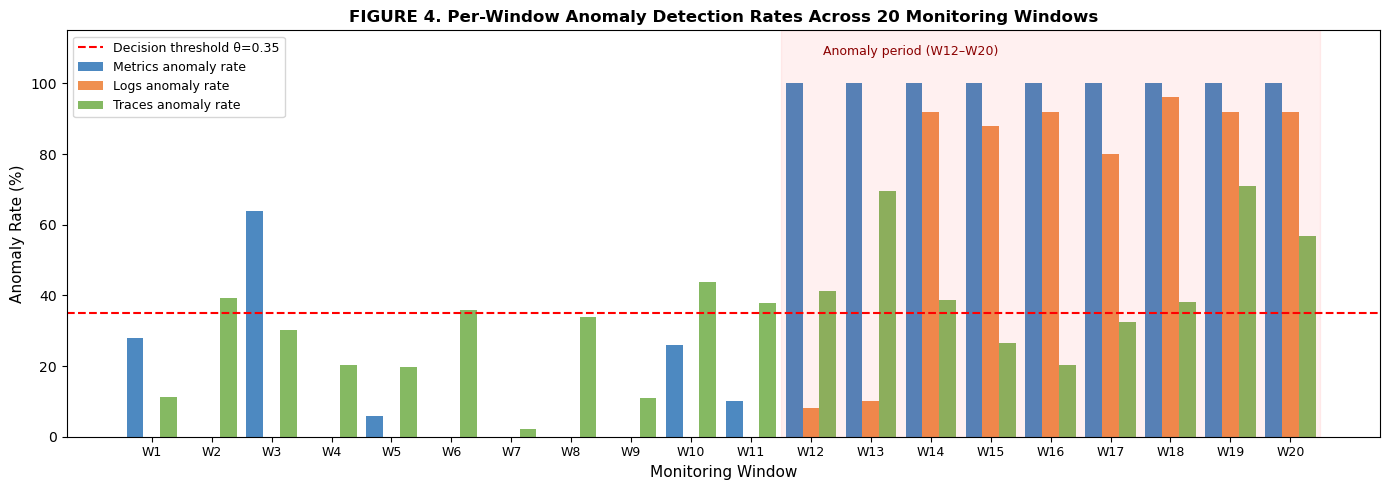

Figure 4 saved.


In [15]:
# FIGURE 4: Per-window anomaly detection rates
windows = list(range(1, N_WINDOWS+1))
sm_pct = [r['_sm']*100 for r in results]
sl_pct = [r['_sl']*100 for r in results]
st_pct = [r['_st']*100 for r in results]

x = np.arange(N_WINDOWS)
width = 0.28

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width, sm_pct, width, label='Metrics anomaly rate', color='#2E75B6', alpha=0.85)
ax.bar(x,         sl_pct, width, label='Logs anomaly rate',    color='#ED7D31', alpha=0.85)
ax.bar(x + width, st_pct, width, label='Traces anomaly rate',  color='#70AD47', alpha=0.85)
ax.axhline(y=THETA*100, color='red', linestyle='--', linewidth=1.5,
           label=f'Decision threshold θ={THETA}')
ax.set_xticks(x)
ax.set_xticklabels([f'W{i}' for i in windows], fontsize=9)
ax.set_xlabel('Monitoring Window', fontsize=11)
ax.set_ylabel('Anomaly Rate (%)', fontsize=11)
ax.set_title('FIGURE 4. Per-Window Anomaly Detection Rates Across 20 Monitoring Windows',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 115)
ax.axvspan(N_NORMAL - 0.5, N_WINDOWS - 0.5, alpha=0.06, color='red', label='_Anomaly period')
ax.text(N_NORMAL + 0.2, 108, 'Anomaly period (W12–W20)', fontsize=9, color='darkred')
plt.tight_layout()
plt.savefig('figure4_per_window_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

## 8. Ablation Study — Table XIII (Response to Reviewers)

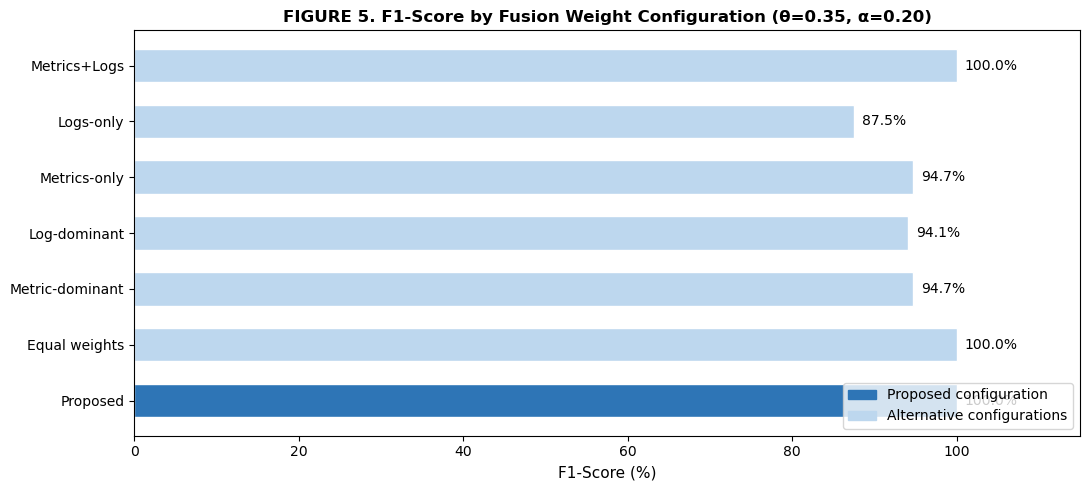

In [17]:
# FIGURE 5: F1 by configuration
fig, ax = plt.subplots(figsize=(11, 5))
labels = [r.split('(')[0].strip() for r in df13['Configuration']]
f1v = df13['F1-Score'].values * 100
colors = ['#2E75B6' if i==0 else '#BDD7EE' for i in range(len(labels))]
bars = ax.barh(labels, f1v, color=colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, f1v):
    ax.text(val+1, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlim(0, 115)
ax.set_xlabel('F1-Score (%)', fontsize=11)
ax.set_title('FIGURE 5. F1-Score by Fusion Weight Configuration (θ=0.35, α=0.20)',
             fontsize=12, fontweight='bold')
p1 = mpatches.Patch(color='#2E75B6', label='Proposed configuration')
p2 = mpatches.Patch(color='#BDD7EE', label='Alternative configurations')
ax.legend(handles=[p1,p2], loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('figure5_ablation_f1.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
CONFIGURATIONS = [
    ('Proposed (0.35, 0.40, 0.25)',        0.35, 0.40, 0.25),
    ('Equal weights (0.33, 0.33, 0.33)',   0.33, 0.33, 0.33),
    ('Metric-dominant (0.60, 0.25, 0.15)', 0.60, 0.25, 0.15),
    ('Log-dominant (0.20, 0.60, 0.20)',    0.20, 0.60, 0.20),
    ('Metrics-only (1.00, 0.00, 0.00)',    1.00, 0.00, 0.00),
    ('Logs-only (0.00, 1.00, 0.00)',       0.00, 1.00, 0.00),
    ('Metrics+Logs (0.45, 0.55, 0.00)',    0.45, 0.55, 0.00),
]

def run_ablation(wm, wl, wt):
    res = fusion_engine(Sm_values, Sl_values, St_values, wm=wm, wl=wl, wt=wt)
    yt = [r['GT'] for r in res]
    yp = [r['_pred'] for r in res]
    tp = sum(1 for a,b in zip(yt,yp) if a==1 and b==1)
    fp = sum(1 for a,b in zip(yt,yp) if a==0 and b==1)
    fn = sum(1 for a,b in zip(yt,yp) if a==1 and b==0)
    tn = sum(1 for a,b in zip(yt,yp) if a==0 and b==0)
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    acc  = (tp+tn)/len(yt)
    return prec, rec, f1, acc

ablation_rows = []
for (label, wm, wl, wt) in CONFIGURATIONS:
    prec, rec, f1, acc = run_ablation(wm, wl, wt)
    ablation_rows.append({'Configuration':label,'w_m':wm,'w_l':wl,'w_t':wt,
                          'Precision':prec,'Recall':rec,'F1-Score':f1,'Accuracy':acc})

df13 = pd.DataFrame(ablation_rows)
fmt = {c: '{:.1%}'.format for c in ['Precision','Recall','F1-Score','Accuracy']}

print('TABLE XIII. Ablation Study: Fusion Weight Sensitivity (θ=0.35, α=0.20)')
display(df13.style.format(fmt)
    .highlight_max(subset=['Precision','Recall','F1-Score','Accuracy'], color='#c6efce')
    .highlight_min(subset=['Precision','Recall','F1-Score','Accuracy'], color='#ffc7ce'))

df13.to_csv('table13_ablation.csv', index=False, float_format='%.4f')
print('Saved: table13_ablation.csv')

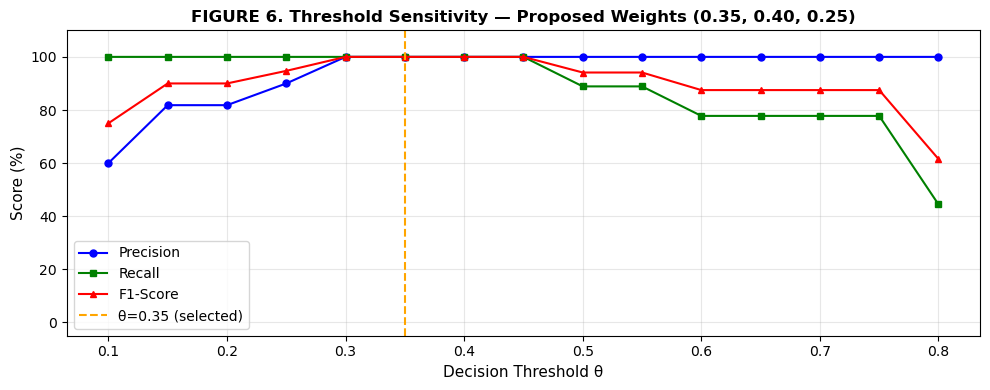

Figure 6 and CSV saved.


In [18]:
# FIGURE 6: Threshold sensitivity
thresholds = [round(t,2) for t in np.arange(0.10, 0.85, 0.05)]
theta_rows = []
for t in thresholds:
    res = fusion_engine(Sm_values, Sl_values, St_values, theta=t)
    yt = [r['GT'] for r in res]
    yp = [r['_pred'] for r in res]
    tp = sum(1 for a,b in zip(yt,yp) if a==1 and b==1)
    fp = sum(1 for a,b in zip(yt,yp) if a==0 and b==1)
    fn = sum(1 for a,b in zip(yt,yp) if a==1 and b==0)
    tn = sum(1 for a,b in zip(yt,yp) if a==0 and b==0)
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    theta_rows.append({'theta':t,'Precision':prec,'Recall':rec,'F1':f1})

df_t = pd.DataFrame(theta_rows)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_t['theta'], df_t['Precision']*100, 'b-o', markersize=5, label='Precision')
ax.plot(df_t['theta'], df_t['Recall']*100,    'g-s', markersize=5, label='Recall')
ax.plot(df_t['theta'], df_t['F1']*100,        'r-^', markersize=5, label='F1-Score')
ax.axvline(x=0.35, color='orange', linestyle='--', linewidth=1.5, label='θ=0.35 (selected)')
ax.set_xlabel('Decision Threshold θ', fontsize=11)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('FIGURE 6. Threshold Sensitivity — Proposed Weights (0.35, 0.40, 0.25)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(-5, 110)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure6_threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
df_t.to_csv('threshold_sensitivity.csv', index=False, float_format='%.4f')
print('Figure 6 and CSV saved.')

## 9. Export All Results

In [19]:
# Save all tables as CSV
df7.to_csv('table7_per_window.csv', index=False)
df8.to_csv('table8_overall_metrics.csv', index=False)
df9.to_csv('table9_layerwise.csv', index=False)
df10.to_csv('table10_root_cause.csv', index=False)
print('All tables saved:')
for f in ['table7_per_window.csv','table8_overall_metrics.csv',
          'table9_layerwise.csv','table10_root_cause.csv',
          'table13_ablation.csv','threshold_sensitivity.csv']:
    print(f'  {f}')
print('\nAll figures saved:')
for f in ['figure4_per_window_rates.png','figure5_ablation_f1.png',
          'figure6_threshold_sensitivity.png']:
    print(f'  {f}')

All tables saved:
  table7_per_window.csv
  table8_overall_metrics.csv
  table9_layerwise.csv
  table10_root_cause.csv
  table13_ablation.csv
  threshold_sensitivity.csv

All figures saved:
  figure4_per_window_rates.png
  figure5_ablation_f1.png
  figure6_threshold_sensitivity.png
